In [1]:
# load a matrix from a space-separated file and show it as an image
import sys
sys.path.append('/homes/ar2342/one_more_dir/contextual_frogs/experimental/optim/')
sys.path.append('/homes/ar2342/one_more_dir/contextual_frogs/')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import os
from stat_utils import bic_gaussian_from_rmse
from memory_upd_utils import polarity, extract_mem_updates, extract_adaptation_measurements
from optimise_clnn import load_subject_data

# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_tryMU5opt3/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_tryMU5opt3/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/deleteme/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_tryMU5opt3withSaves/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_tryMU5opt3withSavesRMSprop/'


# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_tryMU5opt3withSavesRMSprop_LRflr1em1/'
result_path =    '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/MU_NEWveryFudgeDisabled_LRrecover5em3_noLRminWout/'

# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/experimental_uMUm2/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_LRmin_basicBwdCapatRMSprop_M2noAnoLRD_injMU_AmpliBeginEnd/'
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_LRmin_basicBwdCapatRMSprop_M2noAnoLRD_injMU_AmpliBeginEndX20/'


# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_LRmin_basicBwdCapatRMSprop_M2noAnoLRD_injMU/'


In [2]:


a_exp = np.loadtxt(os.path.join(result_path, 'a_exp.txt'))
a_pred = np.loadtxt(os.path.join(result_path, 'a_pred.txt'))


# seeds = 32#18 #72# 18*8 #72 #18 #32
# subjs = a_exp.shape[1] // seeds

subjs =24
seeds = a_exp.shape[1] // subjs

In [3]:
rmse = np.sqrt(np.nanmean((a_exp - a_pred) ** 2,axis=0)).reshape([subjs, seeds])
n_samples = np.sum(~np.isnan(a_exp),axis=0).reshape([subjs, seeds])
#ensure n_samples is same in every row
assert np.all(n_samples == n_samples[:, [0]])
n_samples = n_samples[:, 0]

best_seed_idx = np.nanargmin(rmse, axis=1)
best_rmse = np.nanmin(rmse, axis=1)

/tmp/ipykernel_1503999/485645433.py:1: RuntimeWarning: Mean of empty slice
  rmse = np.sqrt(np.nanmean((a_exp - a_pred) ** 2,axis=0)).reshape([subjs, seeds])


In [4]:
#pack best_rmse calculation into a function, that receives a result_path and returns best_rmse
def calculate_best_rmse(result_path,n_seeds=18):
    a_exp = np.loadtxt(os.path.join(result_path, 'a_exp.txt'))
    a_pred = np.loadtxt(os.path.join(result_path, 'a_pred.txt'))

    subjs = a_exp.shape[1] // n_seeds

    rmse = np.sqrt(np.nanmean((a_exp - a_pred) ** 2,axis=0)).reshape([subjs, n_seeds])
    n_samples = np.sum(~np.isnan(a_exp),axis=0).reshape([subjs, n_seeds])
    #ensure n_samples is same in every row
    assert np.all(n_samples == n_samples[:, [0]])
    n_samples = n_samples[:, 0]

    best_seed_idx = np.nanargmin(rmse, axis=1)
    best_rmse = np.nanmin(rmse, axis=1)
    
    return best_rmse

In [5]:
n_samples

array([292, 292, 292, 292, 292, 292, 292, 292, 292, 292, 292, 292, 292,
       292, 292, 292, 292, 292, 292, 292, 292, 292, 292, 292])

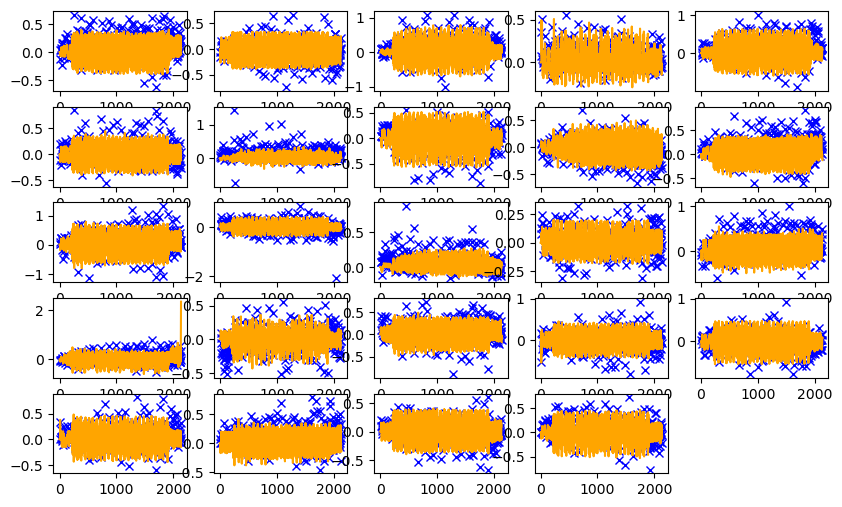

In [6]:
preds = {}
plt.figure(figsize=(10, 6))
plt.subplot(5, 5, 1)
for ii, (this_exp, this_pred) in enumerate(zip(a_exp.T, a_pred.T)):
    plt.subplot(5, 5, 1 + ii//seeds)
    if ii % seeds == 0:
        plt.plot(this_exp,'x', label='Experimental', color='blue')
    if ii % seeds == best_seed_idx[ii//seeds]:
        plt.plot(this_pred, label='Predicted', color='orange')
        preds[ii//seeds+1] = this_pred
    # plt.xlabel('trials')
    # plt.ylabel('adaptation')
    # plt.title('Experimental vs Predicted Data')

In [7]:
experimental_data = {}
loss_traces= {}
output_traces= {}
prior_out_batch = {}
posterior_out_batch = {}
for i in range(1,25): 
    experimental_data[i] = load_subject_data(f'/homes/ar2342/frogs_project/data/COIN_data/trial_data_memory_updating_participant{i}.csv')

In [8]:
outs = []
outs_ini = []
fit_outs = []
fit_outs_ini = []

for i in range(1, 25):
            ys = experimental_data[i][1]
            qs = experimental_data[i][2]
            aa = experimental_data[i][0]
            outs.append(extract_mem_updates(ys, qs, aa,-32))
            outs_ini.append(extract_mem_updates(ys, qs, aa,16))
            # fit_outs.append(extract_mem_updates(ys, qs, mean_as[i-1],-32))
            these_preds = np.mean(preds[i], axis=1) if len(preds[i].shape) > 1 else preds[i]
            try:
                fit_outs.append(extract_mem_updates(ys, qs, these_preds,-32))
                fit_outs_ini.append(extract_mem_updates(ys, qs, these_preds,16))
            except:
                # fit_outs.append(None)
                pass

# rmse = np.sqrt(np.nanmean((a_exp - a_pred) ** 2,axis=0)).reshape([subjs, seeds])
# n_samples = np.sum(~np.isnan(a_exp),axis=0).reshape([subjs, seeds])
# best_seed_idx = np.argmin(rmse, axis=1)
# best_rmse = rmse[np.arange(subjs), best_seed_idx]

Text(0.5, 1.0, 'model')

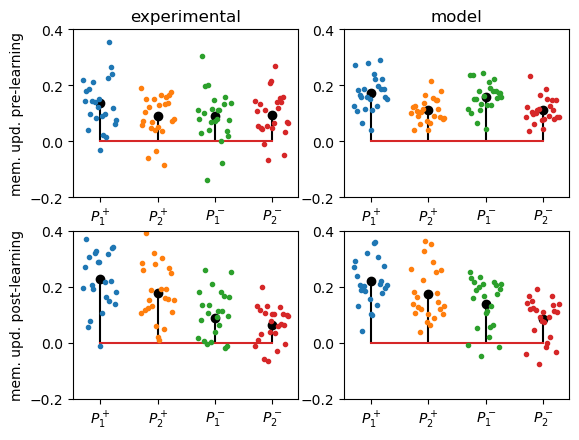

In [9]:
mode_names = ['$P^+_1$', '$P^+_2$', '$P^-_1$', '$P^-_2$']
y_alignment = np.array([1,1,-1,-1])

for ii, these_outs in enumerate([outs_ini, fit_outs_ini, outs, fit_outs]):
    plt.subplot(2,2,ii+1)
    plt.stem(np.mean(y_alignment * np.mean(these_outs, axis=-1),axis=0), 'xk')
    for ii in range(4):
        xdata = -0.3+0.6/24*np.arange(24) + ii
        ydata = y_alignment[ii] * np.mean(these_outs, axis=-1)[:,ii]
        plt.plot(xdata, ydata,'.')
    plt.ylim([-0.2, 0.4])

    # plt.ylim([-0.1, 0.6])
    plt.xticks(np.arange(4), mode_names)
    # plt.ylabel('memory update')
plt.subplot(2,2,1); plt.ylabel('mem. upd. pre-learning')
plt.subplot(2,2,3); plt.ylabel('mem. upd. post-learning')
plt.subplot(2,2,1); plt.title('experimental')
plt.subplot(2,2,2); plt.title('model')


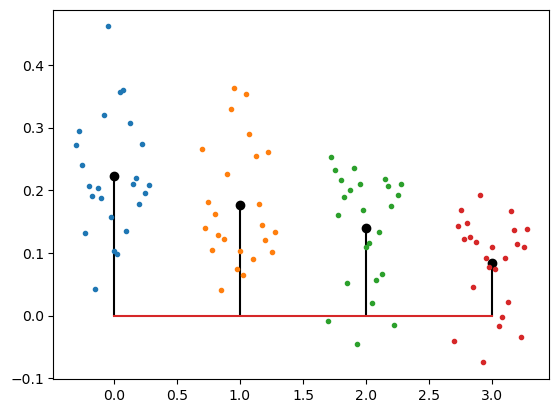

In [10]:
these_outs = fit_outs
plt.stem(np.nanmean(y_alignment * np.nanmean(these_outs, axis=-1),axis=0), 'xk')
for ii in range(4):
    xdata = -0.3+0.6/24*np.arange(24) + ii
    ydata = y_alignment[ii] * np.nanmean(these_outs, axis=-1)[:,ii]
    plt.plot(xdata, ydata,'.')

In [11]:
y_alignment * np.nanmean(these_outs, axis=-1).mean(axis=0)

array([0.22303474, 0.17647686, 0.13962162, 0.08451291])

In [12]:
outs = []
outs_ini = []
fit_outs = []
fit_outs_ini = []

ada = []
fit_ada = []

for i in range(1, 25):
            ys = experimental_data[i][1]
            qs = experimental_data[i][2]
            aa = experimental_data[i][0]
            outs.append(extract_mem_updates(ys, qs, aa,-32))
            outs_ini.append(extract_mem_updates(ys, qs, aa,16))
            ada.append(extract_adaptation_measurements(ys, qs, aa))
            # fit_outs.append(extract_mem_updates(ys, qs, mean_as[i-1],-32))
            these_preds = np.mean(preds[i], axis=1) if len(preds[i].shape) > 1 else preds[i]
            try:
                fit_outs.append(extract_mem_updates(ys, qs, these_preds,-32))
                fit_outs_ini.append(extract_mem_updates(ys, qs, these_preds,16))
                fit_ada.append(extract_adaptation_measurements(ys, qs, these_preds))
            except:
                # fit_outs.append(None)
                pass


(-0.05, 0.85)

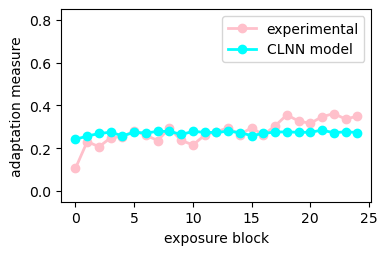

In [13]:
ada_all = [this_ada[1] for this_ada in ada] + [-1*np.array(this_ada[-1]) for this_ada in ada] 
fit_ada_all = [this_ada[1] for this_ada in fit_ada] + [-1*np.array(this_ada[-1]) for this_ada in fit_ada]
plt.figure(figsize=(4,2.5))
plt.plot(np.mean(ada_all, axis=0), label='experimental', color='pink', linewidth=2, marker='o')
plt.plot(np.nanmean(fit_ada_all, axis=0), label='CLNN model', color='cyan', linewidth=2, marker='o')
plt.xlabel('exposure block')
plt.ylabel('adaptation measure')
plt.legend()
plt.ylim([-0.05, 0.85])

In [14]:
outs = []
outs_ini = []
fit_outs = []
fit_outs_ini = []

ada = []
ada_manu = []
fit_ada = []
fit_ada_manu = []

for i in range(1, 25):
            ys = experimental_data[i][1]
            qs = experimental_data[i][2]
            aa = experimental_data[i][0]
            outs.append(extract_mem_updates(ys, qs, aa,-32))
            outs_ini.append(extract_mem_updates(ys, qs, aa,16))
            ada.append(extract_adaptation_measurements(ys, qs, aa))
            ada_manu.append(extract_adaptation_measurements(ys, qs, aa, what_to_return='all_data_dict'))
            # fit_outs.append(extract_mem_updates(ys, qs, mean_as[i-1],-32))
            these_preds = np.mean(preds[i], axis=1) if len(preds[i].shape) > 1 else preds[i]
            try:
                fit_outs.append(extract_mem_updates(ys, qs, these_preds,-32))
                fit_outs_ini.append(extract_mem_updates(ys, qs, these_preds,16))
                fit_ada.append(extract_adaptation_measurements(ys, qs, these_preds))
                fit_ada_manu.append(extract_adaptation_measurements(ys, qs, these_preds, what_to_return='all_data_dict'))
            except:
                # fit_outs.append(None)
                pass


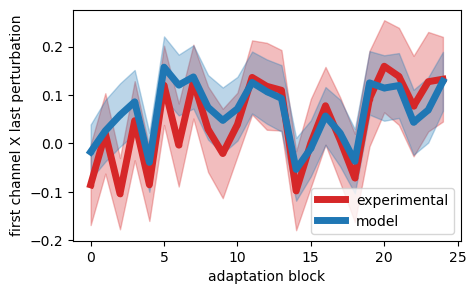

In [15]:
plt.figure(figsize=(5,3))

fit_ada_to_pull = []
def pull_ada_measure(ada_manu):
    ada_to_pull = []
    for this_ada_manu_ in ada_manu:
        this_ada_manu = np.array(this_ada_manu_)
        yprev = this_ada_manu[:, 0]
        qprev = this_ada_manu[:, 3]
        qthis = this_ada_manu[:, 4]
        athis = this_ada_manu[:, -2]
        apair = this_ada_manu[:, -2:]
        qpair = this_ada_manu[:, 4:6]
        ada_to_pull.append(yprev*athis)
    return np.array(ada_to_pull)
    # ada_to_pull.append(np.mean(apair*qpair,axis=1))
# plt.plot(np.mean(ada_to_pull, axis=0), '.-')
# plt.plot(ada_to_pull, '.-')
# plt.plot(np.mean(ada_to_pull, axis=0), '.-', linewidth=5)
ada_to_plot = pull_ada_measure(ada_manu)
fit_ada_to_plot = pull_ada_measure(fit_ada_manu)
colors = ['tab:red', 'tab:blue']
info = ['experimental', 'model']
for this_data, color, label in zip([ada_to_plot, fit_ada_to_plot], colors, info):
    y = np.mean(this_data, axis=0)
    ysdes = np.std(this_data, axis=0)/np.sqrt(this_data.shape[0])
    x = np.arange(len(y))
    plt.fill_between(x, y-ysdes, y+ysdes, alpha=0.3, color=color,label=None)
    plt.plot(y, '.-', linewidth=5, color=color, label=label)
plt.xlabel('adaptation block')
plt.ylabel('first channel X last perturbation')
plt.legend()



In [16]:
best_rmse

array([0.14545801, 0.12710179, 0.18730913, 0.11806814, 0.17503661,
       0.16093497, 0.19813267, 0.13777711, 0.11161612, 0.17114081,
       0.20637041, 0.21039576, 0.12627267, 0.08616426, 0.18178669,
       0.14543596, 0.15084316, 0.13788626, 0.16373182, 0.14033735,
       0.14397965, 0.14251441, 0.11474839, 0.15962181])

In [17]:
 gugu =[0.1442, 0.1466, 0.1765, 0.1366, 0.1575, 0.1884, 0.1798, 0.142,  0.1177, 0.172,
 0.2078, 0.2256, 0.1326, 0.097,  0.181,  0.1615, 0.1638, 0.1799, 0.1733, 0.1693,
 0.1436, 0.1525, 0.1525, 0.1857]

In [18]:
(best_rmse - np.array(gugu))

array([ 0.00125801, -0.01949821,  0.01080913, -0.01853186,  0.01753661,
       -0.02746503,  0.01833267, -0.00422289, -0.00608388, -0.00085919,
       -0.00142959, -0.01520424, -0.00632733, -0.01083574,  0.00078669,
       -0.01606404, -0.01295684, -0.04201374, -0.00956818, -0.02896265,
        0.00037965, -0.00998559, -0.03775161, -0.02607819])

In [19]:
outs_np = np.array(outs)

In [20]:
outs_np.shape

(24, 4, 8)

In [21]:
outs_paper = outs_np.mean(axis=-1)

In [22]:
from scipy.stats import ttest_rel

In [23]:
#ttest every column again each of others (double-tailed) report pvalues
for i in range(4):
    for j in range(4):
        if i != j:
            t_stat, p_value = ttest_rel(outs_paper[:, i], outs_paper[:, j])
            print(f'Comparison between mode {i+1} and mode {j+1}: t-statistic = {t_stat:.4f}, p-value = {p_value:.4e}')

Comparison between mode 1 and mode 2: t-statistic = 2.6713, p-value = 1.3636e-02
Comparison between mode 1 and mode 3: t-statistic = 11.6338, p-value = 4.0919e-11
Comparison between mode 1 and mode 4: t-statistic = 13.9737, p-value = 1.0002e-12
Comparison between mode 2 and mode 1: t-statistic = -2.6713, p-value = 1.3636e-02
Comparison between mode 2 and mode 3: t-statistic = 8.8665, p-value = 7.0307e-09
Comparison between mode 2 and mode 4: t-statistic = 13.0000, p-value = 4.4020e-12
Comparison between mode 3 and mode 1: t-statistic = -11.6338, p-value = 4.0919e-11
Comparison between mode 3 and mode 2: t-statistic = -8.8665, p-value = 7.0307e-09
Comparison between mode 3 and mode 4: t-statistic = -1.1679, p-value = 2.5483e-01
Comparison between mode 4 and mode 1: t-statistic = -13.9737, p-value = 1.0002e-12
Comparison between mode 4 and mode 2: t-statistic = -13.0000, p-value = 4.4020e-12
Comparison between mode 4 and mode 3: t-statistic = 1.1679, p-value = 2.5483e-01


/tmp/ipykernel_1503999/3837373708.py:8: RuntimeWarning: Mean of empty slice
  rmse = np.sqrt(np.nanmean((a_exp - a_pred) ** 2,axis=0)).reshape([subjs, n_seeds])


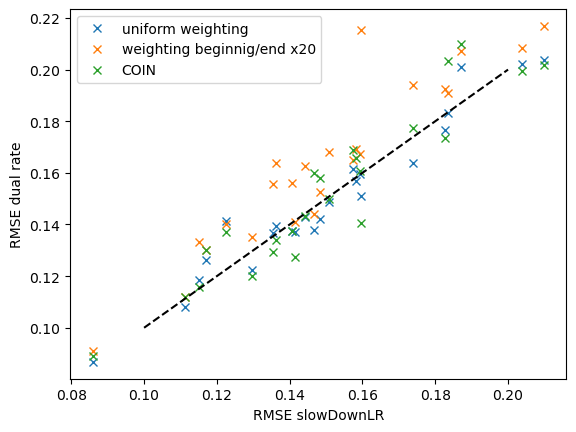

In [24]:
result_path1 = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_tryMU5opt3withSavesRMSprop_LRflr1em1/'
result_path2 = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_LRmin_basicBwdCapatRMSprop_M2noAnoLRD_injMU/'
result_path3 = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/hello_part2_LRmin_basicBwdCapatRMSprop_M2noAnoLRD_injMU_AmpliBeginEndX20/'
coin_rmse = np.loadtxt('/homes/ar2342/frogs_project/COIN/examples/figs/MU_rmses_P1000r10.txt', delimiter=',')
# result_path2 = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/experimental_uMUm2/'
best_rmse1 = calculate_best_rmse(result_path1,n_seeds=72)
best_rmse2 = calculate_best_rmse(result_path2,n_seeds=18)
best_rmse3 = calculate_best_rmse(result_path3,n_seeds=32)
plt.plot(best_rmse1,best_rmse2,'x')
plt.plot(best_rmse1,best_rmse3,'x')
plt.plot(best_rmse1,coin_rmse,'x')
plt.plot([0.1, 0.2], [0.1, 0.2], 'k--') # add a diagonal line for reference

plt.xlabel('RMSE slowDownLR')
plt.ylabel('RMSE dual rate')
plt.legend(['uniform weighting', 'weighting beginnig/end x20', 'COIN'])

Text(0, 0.5, 'RMSE dual rate')

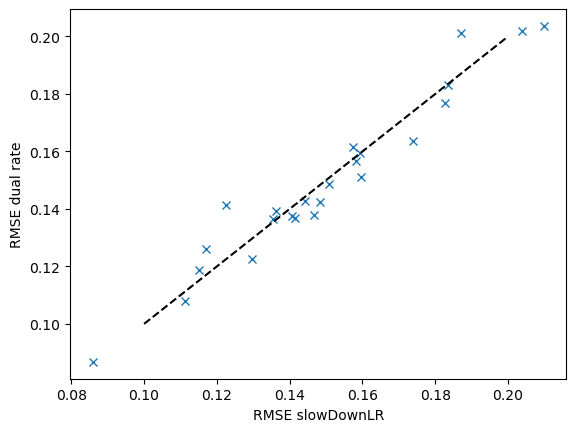

In [25]:
plt.plot(best_rmse1,best_rmse2,'x')
plt.plot([0.1, 0.2], [0.1, 0.2], 'k--') # add a diagonal line for reference
plt.xlabel('RMSE slowDownLR')
plt.ylabel('RMSE dual rate')